In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
pd.set_option('display.max_columns', None)

In [23]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [24]:
df.head(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,3,2,2,2.0,New Property,850.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8597.0,2,2,2,4.0,New Property,1226.0,1,1,0,0,0,0,38
2,flat,breez global hill view,sohna road,0.32,5470.0,2,2,1,17.0,New Property,1000.0,0,0,0,0,0,0,49
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3,4,3+,10.0,Relatively New,1615.0,0,1,0,0,1,1,174
4,flat,suncity avenue,sector 102,0.48,9023.0,2,2,1,5.0,Relatively New,582.0,0,0,1,0,0,0,159


In [5]:
df2 = df.drop(columns=['society','price_per_sqft'])

In [6]:
df2.head(2)

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 36,0.82,3,2,2,2.0,New Property,850.0,0,0,0,0,0,0,8
1,flat,sector 89,0.95,2,2,2,4.0,New Property,1226.0,1,1,0,0,0,0,38


# LUXURY SCORE

<Axes: xlabel='luxury_score'>

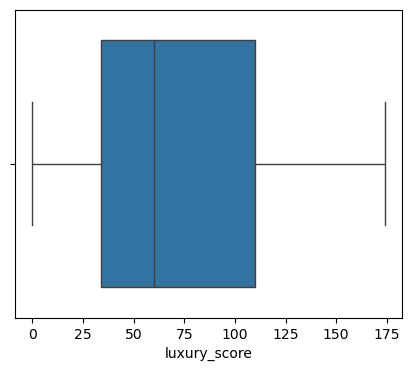

In [7]:
plt.figure(figsize=(5,4))
sns.boxplot(x=df['luxury_score'])

In [8]:
def categorize(luxury):
    if 0 <= luxury < 50:
        return "Low"
    elif 50 <= luxury < 150:
        return "Medium"
    elif 150 <= luxury < 175:
        return 'High'
    else:
        return None

In [9]:
df2['luxury_category'] = df2['luxury_score'].apply(categorize)

In [10]:
df2.sample(5)

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
2282,flat,sector 83,1.75,3,3,3+,11.0,Relatively New,1549.0,0,1,0,0,0,0,120,Medium
881,flat,sector 69,1.43,3,3,2,1.0,Relatively New,1305.0,0,0,0,1,0,0,86,Medium
1163,flat,sector 92,0.21,1,1,1,0.0,Relatively New,336.0,0,0,0,0,0,0,63,Medium
2622,flat,sector 92,1.68,3,4,3+,15.0,Relatively New,1804.0,0,1,0,0,0,1,174,High
1003,flat,sector 102,1.75,3,3,3,10.0,Relatively New,1465.0,1,1,0,1,1,0,49,Low


# floorNum

<Axes: xlabel='floorNum'>

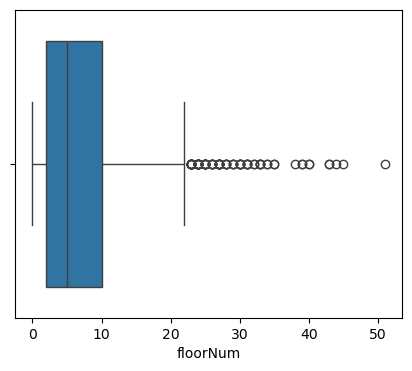

In [11]:
plt.figure(figsize=(5,4))
sns.boxplot(x=df['floorNum'])

In [12]:
def categorize_floor(floor):
    if 0 <= floor < 3:
        return 'Low floor'
    elif 3 <= floor < 11:
        return 'Mid floor'
    elif 11 <= floor < 60:
        return 'High floor'
    else:
        return None

In [13]:
df2['floor_category'] = df['floorNum'].apply(categorize_floor)

In [14]:
df2.sample(5)

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
2441,house,sector 24,3.25,4,4,3,3.0,Old Property,1070.0,0,0,0,0,0,0,15,Low,Mid floor
532,flat,sector 59,5.00,4,4,3+,13.0,Relatively New,4254.0,1,1,1,1,0,1,174,High,High floor
2106,flat,sector 37d,2.08,4,4,3,0.0,New Property,2211.0,1,1,0,1,0,0,121,Medium,Low floor
670,flat,sohna road,0.35,2,2,1,2.0,New Property,699.0,0,0,0,0,0,0,74,Medium,Low floor
2779,flat,sector 109,2.30,3,4,3+,10.0,New Property,2339.0,0,1,0,0,1,0,74,Medium,Mid floor


In [15]:
df2.drop(columns=['luxury_score','floorNum'],inplace=True)

In [16]:
df2.head(3)

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 36,0.82,3,2,2,New Property,850.0,0,0,0,0,0,0,Low,Low floor
1,flat,sector 89,0.95,2,2,2,New Property,1226.0,1,1,0,0,0,0,Low,Mid floor
2,flat,sohna road,0.32,2,2,1,New Property,1000.0,0,0,0,0,0,0,Low,High floor


In [73]:
from sklearn.preprocessing import OrdinalEncoder

data_df = df2.copy()

categorical_col = data_df.select_dtypes(include=['object']).columns

oe = OrdinalEncoder()
data_df[categorical_col] = oe.fit_transform(data_df[categorical_col])

In [74]:
X_label = data_df.drop('price', axis=1)
y_label = data_df['price']

In [76]:
X_label.head()

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,36.0,3,2,2.0,1.0,850.0,0,0,0,0,0,0,1.0,1.0
1,0.0,95.0,2,2,2.0,1.0,1226.0,1,1,0,0,0,0,1.0,2.0
2,0.0,103.0,2,2,1.0,1.0,1000.0,0,0,0,0,0,0,1.0,0.0
3,0.0,99.0,3,4,4.0,3.0,1615.0,0,1,0,0,1,1,0.0,2.0
4,0.0,5.0,2,2,1.0,3.0,582.0,0,0,1,0,0,0,0.0,2.0


In [78]:
y_label.sample(5)

360     0.71
2060    2.12
3550    4.50
1479    0.27
2474    0.36
Name: price, dtype: float64

# 1. Co-relation Technique

<Axes: >

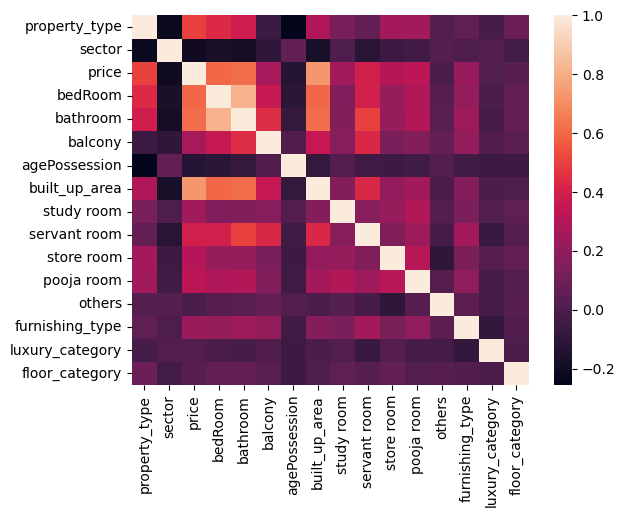

In [79]:
sns.heatmap(data_df.corr())

In [90]:
corr_df = data_df.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coef'})
corr_df

,feature,corr_coef
0,sector,-0.206955
1,price,1.000000
2,bedRoom,0.597771
3,bathroom,0.613008
4,balcony,0.261918
5,agePossession,-0.132774
6,built_up_area,0.731149
7,study room,0.247343
8,servant room,0.392991
9,store room,0.299813


# 2. Random Forest Feature Importance

In [91]:
from sklearn.ensemble import RandomForestRegressor

rf_label = RandomForestRegressor(n_estimators = 100,random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.643838
1,sector,0.103092
0,property_type,0.098427
2,bedRoom,0.029605
3,bathroom,0.026373
8,servant room,0.019406
5,agePossession,0.014871
4,balcony,0.013553
12,furnishing_type,0.011053
13,luxury_category,0.010206


# 3. Gradient Boosting Technique

In [92]:
from sklearn.ensemble import GradientBoostingRegressor

gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.672931
1,sector,0.111839
0,property_type,0.102000
2,bedRoom,0.036537
3,bathroom,0.035369
8,servant room,0.022225
7,study room,0.008974
5,agePossession,0.003822
12,furnishing_type,0.002154
4,balcony,0.001494


# 4. Permutation Importance

In [94]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

# This method shuffles the values of a particular columns and then calculates the r2 score , if the score is impacted a lot then we can say
# that the feature is important for the dataset. If the value of the score doesn't change much then we can conclude that the feature is
# not useful and therefore we can remove it.

,feature,permutation_importance
6,built_up_area,0.637109
0,property_type,0.232447
1,sector,0.118814
3,bathroom,0.021963
8,servant room,0.013229
2,bedRoom,0.009288
4,balcony,0.008268
7,study room,0.005394
5,agePossession,0.003025
11,others,0.002755


# 5. LASSO

In [95]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.445044
0,property_type,0.730266
3,bathroom,0.291660
7,study room,0.198580
12,furnishing_type,0.179111
9,store room,0.161230
8,servant room,0.149894
10,pooja room,0.086753
2,bedRoom,0.081700
13,luxury_category,0.064348


# 6. RFE

In [96]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
6,built_up_area,0.642636
0,property_type,0.103857
1,sector,0.102280
2,bedRoom,0.031445
3,bathroom,0.022797
8,servant room,0.019341
4,balcony,0.014489
5,agePossession,0.013770
12,furnishing_type,0.012442
13,luxury_category,0.009089


# 7. Linear Regression Weights

In [99]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
6,built_up_area,1.447781
0,property_type,0.728902
3,bathroom,0.298448
7,study room,0.206930
12,furnishing_type,0.188055
9,store room,0.165667
8,servant room,0.158825
10,pooja room,0.089758
2,bedRoom,0.083870
13,luxury_category,0.075558


In [101]:
final_fi_df = corr_df.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').set_index('feature')

In [102]:
final_fi_df

,corr_coef,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs
feature,,,,,,,
sector,-0.206955,0.103092,0.111839,0.118814,-0.067515,0.102280,-0.076644
bedRoom,0.597771,0.029605,0.036537,0.009288,0.081700,0.031445,0.083870
bathroom,0.613008,0.026373,0.035369,0.021963,0.291660,0.022797,0.298448
balcony,0.261918,0.013553,0.001494,0.008268,-0.043855,0.014489,-0.066731
agePossession,-0.132774,0.014871,0.003822,0.003025,-0.000000,0.013770,-0.003769
built_up_area,0.731149,0.643838,0.672931,0.637109,1.445044,0.642636,1.447781
study room,0.247343,0.008040,0.008974,0.005394,0.198580,0.008964,0.206930
servant room,0.392991,0.019406,0.022225,0.013229,0.149894,0.019341,0.158825
store room,0.299813,0.005174,0.001091,-0.001845,0.161230,0.004227,0.165667


In [103]:
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [105]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.741091
sector             0.124796
bathroom           0.030274
bedRoom            0.030010
servant room       0.021033
balcony            0.010759
agePossession      0.009959
study room         0.008887
furnishing_type    0.005872
luxury_category    0.005676
floor_category     0.003934
others             0.002995
pooja room         0.002364
store room         0.002350
dtype: float64

In [106]:
#trying to check if there is an effect on accuracy score if the last three columns with least importance are dropped

In [107]:
# with all columns
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators = 100,random_state=42)

scores = cross_val_score(rf,X_label,y_label,cv=5,scoring='r2')

In [108]:
scores.mean()

np.float64(0.8129695747106546)

In [110]:
#Now without those three columns
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [112]:
scores.mean()

np.float64(0.8104971726532229)

In [113]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [114]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)

In [17]:
df2.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 36,0.82,3,2,2,New Property,850.0,0,0,0,0,0,0,Low,Low floor
1,flat,sector 89,0.95,2,2,2,New Property,1226.0,1,1,0,0,0,0,Low,Mid floor
2,flat,sohna road,0.32,2,2,1,New Property,1000.0,0,0,0,0,0,0,Low,High floor
3,flat,sector 92,1.60,3,4,3+,Relatively New,1615.0,0,1,0,0,1,1,High,Mid floor
4,flat,sector 102,0.48,2,2,1,Relatively New,582.0,0,0,1,0,0,0,High,Mid floor


In [19]:
df2.drop(columns=['pooja room', 'study room', 'others'],inplace=True)

In [20]:
df2.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 36,0.82,3,2,2,New Property,850.0,0,0,0,Low,Low floor
1,flat,sector 89,0.95,2,2,2,New Property,1226.0,1,0,0,Low,Mid floor
2,flat,sohna road,0.32,2,2,1,New Property,1000.0,0,0,0,Low,High floor
3,flat,sector 92,1.60,3,4,3+,Relatively New,1615.0,1,0,1,High,Mid floor
4,flat,sector 102,0.48,2,2,1,Relatively New,582.0,0,1,0,High,Mid floor


In [26]:
df2.to_csv('gurgaon_properties_post_feature_selection_v2.csv', index=False)